# NetFlow Unsupervised Deep Learning Lab (Autoencoder)

This notebook builds an **unsupervised deep learning** model for network flow (NetFlow/IPFIX-style) records.

Unlike supervised classification (where we predict `Label`), unsupervised learning tries to find **structure** in the data without using labels.

## Objectives
- Treat each row as a *single network flow record* and learn a neural network representation without using labels.
- Train an **autoencoder** to learn a compressed embedding of flows.
- Use **reconstruction error** as an anomaly score (flows that the model cannot reconstruct well may be unusual).
- Cluster flows in the learned embedding space (optional) and interpret clusters.
- (If `Label` exists) use it **only after training** to interpret results (sanity-check), not to train the model.

## What is an autoencoder?
An **autoencoder** is a neural network trained to copy its input to its output:
- **Encoder**: maps the input feature vector $x$ into a low-dimensional representation (embedding) $z$.
- **Decoder**: maps $z$ back into a reconstruction $at{x}$.

Training objective (typical): minimize reconstruction error, e.g. mean squared error (MSE):
$$
\text{MSE}(x,\hat{x})=\frac{1}{d}\sum_{j=1}^{d}\left(x_j-\hat{x}_j\right)^2
$$

Why this is useful in NetFlow:
- Most “normal” traffic forms repeating patterns in flow-level statistics (bytes/packets/duration/ports).
- The autoencoder learns to represent those patterns compactly.
- Flows that do *not* match learned patterns may have larger reconstruction error → potential anomalies or rare behaviors.

Important caveat:
- Unsupervised anomaly scores are not ground truth. A high score means “unusual under the model,” which could be benign (rare but normal) or suspicious.

In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Optional plotting (the notebook still runs if matplotlib is unavailable)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as e:
    HAS_MPL = False
    print('Matplotlib not available, skipping plots:', e)

# Optional rich display (works in Jupyter; we fall back to print if missing)
try:
    from IPython.display import display
except Exception:
    display = None

In [3]:
# Load dataset
df = pd.read_csv('flows.csv')
df.head(10)

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label
0,25405,443,17,7708.731622,379.0,94.0,210724.0,50384.0,33871.720121,61.358992,0,0,0,VPN
1,55432,8080,6,3024.530486,122.0,1098.0,27084.0,976122.0,331689.829065,403.368392,1,7,1,VIDEO
2,56850,443,6,5081.732696,89.0,44.0,56782.0,34848.0,18031.251441,26.172176,2,6,0,BULK
3,49672,5061,17,5859.682646,308.0,119.0,19404.0,13209.0,5565.659776,72.870841,0,0,0,VOIP
4,50499,443,6,4686.218441,44.0,76.0,16940.0,70072.0,18567.636378,25.607001,1,5,1,WEB
5,33357,443,6,8476.412156,114.0,34.0,126540.0,26894.0,18101.290639,17.460218,2,1,1,BULK
6,15748,443,6,3062.836794,266.0,391.0,139118.0,143106.0,92144.642045,214.507022,0,6,0,VPN
7,39782,443,6,3693.393050,116.0,88.0,30160.0,37840.0,18411.254657,55.233764,2,7,0,VPN
8,64991,443,17,2495.019157,34.0,53.0,2346.0,46163.0,19442.335691,34.869472,0,0,0,WEB
9,48358,1935,6,4272.714279,45.0,637.0,4545.0,348439.0,82613.527832,159.617507,2,5,0,VIDEO


## Preparing the data (same preprocessing principles as other labs)

Autoencoders (like most neural networks) require numeric inputs and are trained with gradient-based optimization, so **preprocessing is critical**.

We will:
- Remove `Label` from features (if present).
- Split columns into numeric vs categorical.
- Impute missing values.
- Scale numeric features.
- One-hot encode categorical features.

Why scaling matters here:
- Reconstruction loss is computed in input space. If one column has a huge scale, it can dominate the loss and training dynamics.
- Standardization makes different features contribute more evenly.

In [4]:
has_label = 'Label' in df.columns
y = df['Label'] if has_label else None
X = df.drop(columns=['Label']) if has_label else df.copy()

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Keep OneHotEncoder dense for easier neural net training
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_trans = preprocess.fit_transform(X)
print('Transformed shape:', X_trans.shape)
print('Numeric feature count:', len(numeric_features))
print('Categorical feature count:', len(categorical_features))

Transformed shape: (50000, 13)
Numeric feature count: 13
Categorical feature count: 0


## Training the autoencoder (unsupervised deep learning model)

We will implement an autoencoder using `sklearn.neural_network.MLPRegressor`:
- The model takes input $x$ and predicts output $at{x}$.
- We train it with targets equal to the inputs: `y = X_trans`.

Architecture idea:
- Use a **bottleneck** hidden layer smaller than the input dimension.
- Example: `(64, 16, 64)` creates an embedding of size 16 in the middle.

Regularization and training stability:
- `alpha` adds L2 regularization.
- `early_stopping=True` stops training when validation score stops improving.

After training, we will compute per-flow reconstruction error as an anomaly score.

In [5]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=(64, 16, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42,
)

autoencoder.fit(X_trans, X_trans)
X_hat = autoencoder.predict(X_trans)

# Reconstruction error per row (mean squared error across features)
recon_mse = np.mean((X_trans - X_hat) ** 2, axis=1)
print('Reconstruction MSE summary:')
pd.Series(recon_mse).describe()

Reconstruction MSE summary:


count    50000.000000
mean         0.000061
std          0.000111
min          0.000002
25%          0.000021
50%          0.000038
75%          0.000070
max          0.010754
dtype: float64

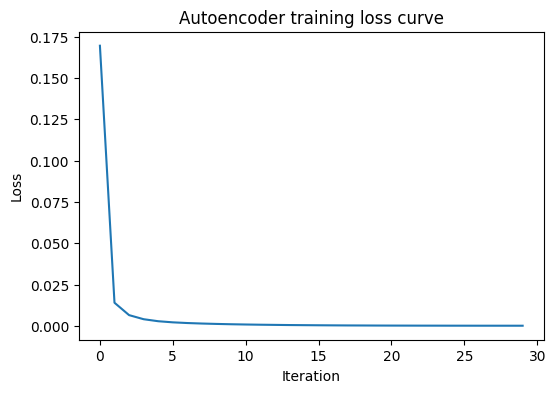

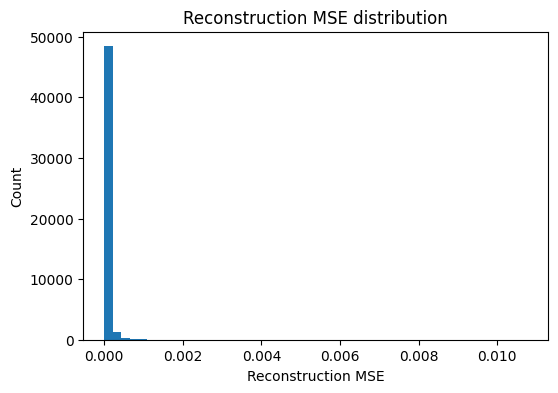

In [6]:
# Optional: plot the loss curve and reconstruction error distribution
if HAS_MPL:
    # Training loss curve
    plt.figure(figsize=(6, 4))
    plt.plot(autoencoder.loss_curve_)
    plt.title('Autoencoder training loss curve')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.show()

    # Reconstruction error histogram
    plt.figure(figsize=(6, 4))
    plt.hist(recon_mse, bins=50)
    plt.title('Reconstruction MSE distribution')
    plt.xlabel('Reconstruction MSE')
    plt.ylabel('Count')
    plt.show()
else:
    print('Matplotlib not available; skipping plots.')

## Using reconstruction error for anomaly detection (unsupervised)

A simple unsupervised anomaly workflow is:
1. Train an autoencoder on your dataset (ideally mostly “normal” traffic).
2. Compute reconstruction error for each flow.
3. Flag flows with high reconstruction error as **unusual**.

How to choose a threshold?
- Common heuristic: flag the top $p$ highest errors (e.g., top 1%).
- In production, you would calibrate using analyst feedback or known incidents.

If `Label` exists, we can check whether certain labels disproportionately appear among the highest-error flows (again: only for interpretation).

In [7]:
df_scores = df.copy()
df_scores['recon_mse'] = recon_mse

# Show the top 20 most unusual flows by reconstruction error
top_anomalies = df_scores.sort_values('recon_mse', ascending=False).head(20)
(display(top_anomalies) if display is not None else top_anomalies)

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label,recon_mse
27429,18090,500,6,140.561063,153.0,321.0,21114.0,190674.0,1.506733e+06,3372.199888,0,5,0,VPN,0.010754
7295,13564,443,6,424.278463,146.0,186.0,207320.0,265608.0,1.114664e+06,782.504955,2,2,0,BULK,0.006540
19825,5487,20000,6,10394.936729,479.0,390.0,90052.0,69810.0,1.537883e+04,83.598392,0,1,1,VOIP,0.005909
1868,30818,443,17,93839.399045,90.0,211.0,12690.0,125756.0,1.475350e+03,3.207608,0,0,0,VIDEO,0.005354
22616,64490,443,6,766.607533,193.0,1493.0,49215.0,756951.0,1.051602e+06,2199.300067,2,3,0,VIDEO,0.003322
46657,63203,10000,6,1568.889766,324.0,475.0,34020.0,37525.0,4.560231e+04,509.277336,0,8,1,VOIP,0.002903
12461,23849,443,17,6713.283911,170.0,1472.0,21420.0,752192.0,1.152360e+05,244.589685,0,0,0,VIDEO,0.002895
14954,58202,1194,6,426.048089,105.0,241.0,13545.0,42657.0,1.319147e+05,812.114898,1,6,1,VPN,0.002797
34527,61528,20,6,70637.371572,86.0,134.0,50482.0,100500.0,2.137424e+03,3.114499,2,5,1,BULK,0.002775
18076,52514,443,17,679.590073,137.0,1079.0,17399.0,1205243.0,1.799087e+06,1789.313952,0,0,0,VIDEO,0.002720


In [8]:
# If labels exist, check which labels appear among the top 1% reconstruction errors
if has_label:
    threshold = np.quantile(recon_mse, 0.99)
    high = df_scores[df_scores['recon_mse'] >= threshold]
    print(f'Top 1% threshold recon_mse >= {threshold:.6f} | count={len(high)}')
    print('Label distribution among high-error flows:')
    print(high['Label'].value_counts(normalize=True).head(10))
else:
    print('No Label column found; skipping label distribution check.')

Top 1% threshold recon_mse >= 0.000385 | count=500
Label distribution among high-error flows:
Label
VIDEO    0.468
VOIP     0.298
VPN      0.128
BULK     0.064
WEB      0.042
Name: proportion, dtype: float64


## Representation learning: embedding flows with the encoder

A major benefit of deep learning in unsupervised settings is **representation learning**: learning an embedding where similarity is more meaningful.

Our autoencoder has a bottleneck hidden layer of size 16. We can extract the activations at that bottleneck to obtain a 16‑dimensional embedding for each flow.

Then we can:
- Cluster flows in embedding space (K-Means on $z$).
- Visualize embeddings with PCA.
- Interpret clusters by comparing flow statistics across clusters.

Note: scikit-learn’s `MLPRegressor` does not expose an “encoder” object directly, but it stores weights (`coefs_`, `intercepts_`). We can do a forward pass and capture the bottleneck activations.

In [10]:
def _relu(x):
    return np.maximum(0.0, x)


def encode_bottleneck(
    mlp_regressor: MLPRegressor,
    X_input: np.ndarray,
    bottleneck_layer_index: int = 1,
) -> np.ndarray:
    """Return hidden-layer activations from an MLPRegressor.

    For hidden_layer_sizes=(64, 16, 64):
    - bottleneck_layer_index=0 -> 64-dim activations (after 1st hidden layer)
    - bottleneck_layer_index=1 -> 16-dim activations (the bottleneck)
    - bottleneck_layer_index=2 -> 64-dim activations (after 3rd hidden layer)
    """

    activ = X_input
    for i, (W, b) in enumerate(
        zip(mlp_regressor.coefs_[:-1], mlp_regressor.intercepts_[:-1])
    ):
        activ = activ @ W + b
        activ = _relu(activ)
        if i == bottleneck_layer_index:
            return activ

    return activ


Z = encode_bottleneck(autoencoder, X_trans, bottleneck_layer_index=1)
print("Embedding shape (Z):", Z.shape)
pd.DataFrame(Z).head()


Embedding shape (Z): (50000, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,2.588867,2.136610,2.513210,1.920093,3.581647,1.826073,2.860811,1.211257,1.377096,0.0,2.911248,1.528167,5.400396,3.043692,2.143553,1.374494
1,2.505723,2.963972,2.516603,2.218552,0.740772,3.282724,2.612188,3.463709,6.123924,0.0,3.235706,3.482085,3.667260,3.697217,3.710060,2.193173
2,2.648451,0.370017,1.179740,2.417588,1.282907,2.065916,2.228314,1.948442,1.059837,0.0,0.464214,1.000084,2.217299,1.704087,1.908744,1.272674
3,1.713895,1.182026,2.207867,2.796978,2.016828,1.264156,1.673786,1.532571,1.434875,0.0,2.067757,0.406400,1.595924,1.385763,1.078891,1.025744
4,2.800499,0.974400,1.427565,1.542782,1.164637,1.540134,2.135710,2.378081,1.656218,0.0,0.471812,1.307620,1.272855,1.244093,0.964574,1.325486


## Clustering in embedding space (optional)

Instead of clustering raw standardized flow features, we can cluster the learned embeddings $z$.

Motivation:
- If the autoencoder learns a useful representation, then flows that behave similarly should be closer in embedding space.
- This can reduce noise and make clustering more stable.

We will choose the number of clusters $K$ using silhouette score on a sample (same idea as the unsupervised K-Means lab).

In [11]:
rng = np.random.default_rng(42)
n = Z.shape[0]
sample_size = min(5000, n)
sample_idx = rng.choice(n, size=sample_size, replace=False)
Z_sample = Z[sample_idx]

rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_sample = km.fit_predict(Z_sample)
    sil = silhouette_score(Z_sample, labels_sample)
    rows.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})

k_summary = pd.DataFrame(rows)
k_summary

,k,inertia,silhouette
0,2,47194.196722,0.477070
1,3,38596.892600,0.288071
2,4,34546.913955,0.283859
3,5,30550.182386,0.247009
4,6,28136.993833,0.232767
5,7,26117.257583,0.231578
6,8,24428.695057,0.194207
7,9,23238.829104,0.203730
8,10,22225.661271,0.194547


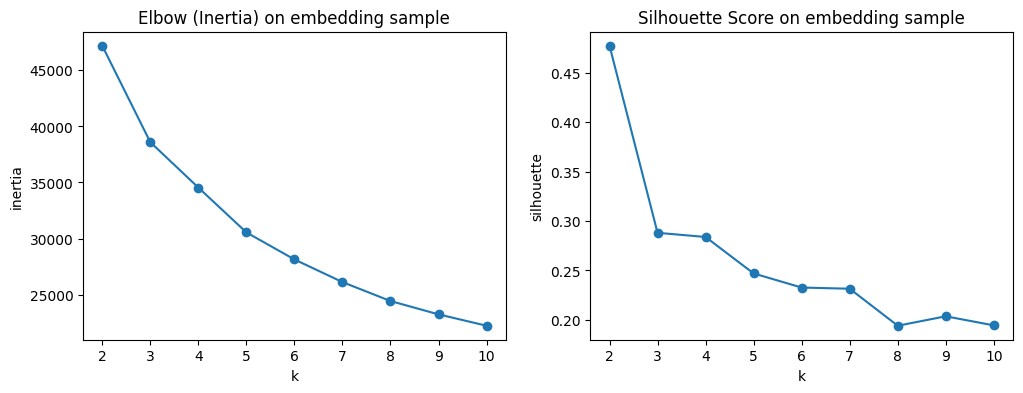

In [12]:
if HAS_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(k_summary['k'], k_summary['inertia'], marker='o')
    ax[0].set_title('Elbow (Inertia) on embedding sample')
    ax[0].set_xlabel('k')
    ax[0].set_ylabel('inertia')

    ax[1].plot(k_summary['k'], k_summary['silhouette'], marker='o')
    ax[1].set_title('Silhouette Score on embedding sample')
    ax[1].set_xlabel('k')
    ax[1].set_ylabel('silhouette')
    plt.show()
else:
    print('Matplotlib not available; skipping K plots.')

In [13]:
k_final = 5
kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
clusters = kmeans.fit_predict(Z)

df_embed = df.copy()
df_embed['cluster'] = clusters

print('Cluster sizes:')
df_embed['cluster'].value_counts().sort_index()

Cluster sizes:


cluster
0    23927
1     7362
2     4766
3    12906
4     1039
Name: count, dtype: int64

In [14]:
# Interpret clusters by numeric feature means
num_cols = df_embed.drop(columns=['Label'], errors='ignore').select_dtypes(include=['int64', 'float64']).columns
summary = df_embed.groupby('cluster')[num_cols].mean(numeric_only=True)
summary.head()

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt
cluster,,,,,,,,,,,,,
0,33505.524345,1020.849292,6.000000,3671.738986,61.464538,110.837965,20906.810967,7.403528e+04,29721.596889,57.561571,0.985414,4.914365,0.484808
1,31883.783890,2056.483836,7.270035,4309.213041,241.467808,185.288101,126490.309970,9.863598e+04,84639.589993,174.165499,0.945395,4.805759,0.489269
2,33693.950483,2047.776332,10.304448,6678.207553,110.798573,1059.345783,21407.536089,1.016303e+06,211715.546774,249.243530,0.621486,3.105329,0.311372
3,33633.015962,6139.682318,16.652255,4540.376030,173.240508,265.022548,29628.383078,1.164329e+05,35300.947625,115.137096,0.028824,0.084689,0.006586
4,33170.899904,2007.837344,9.917228,2721.887393,123.360924,1141.435996,31293.326275,1.249662e+06,601482.869341,636.709771,0.643888,3.318576,0.359962


In [15]:
# If labels exist, show Label x Cluster (post-hoc interpretation only)
if has_label:
    ct = pd.crosstab(df_embed['Label'], df_embed['cluster'])
    print('Label x Cluster counts:')
    (display(ct) if display is not None else print(ct))

    ct_norm = pd.crosstab(df_embed['Label'], df_embed['cluster'], normalize='index')
    print('Label x Cluster fractions (rows sum to 1):')
    (display(ct_norm) if display is not None else print(ct_norm))
else:
    print('No Label column found; skipping label-vs-cluster interpretation.')

Label x Cluster counts:


cluster,0,1,2,3,4
Label,,,,,
BULK,3463,3086,45,808,27
VIDEO,1934,240,4666,2137,957
VOIP,371,663,33,6430,0
VPN,3388,3349,18,875,54
WEB,14771,24,4,2656,1


Label x Cluster fractions (rows sum to 1):


cluster,0,1,2,3,4
Label,,,,,
BULK,0.466146,0.415399,0.006057,0.108763,0.003634
VIDEO,0.194685,0.024159,0.469700,0.215120,0.096336
VOIP,0.049486,0.088435,0.004402,0.857676,0.000000
VPN,0.440916,0.435841,0.002343,0.113873,0.007028
WEB,0.846185,0.001375,0.000229,0.152154,0.000057


## (Optional) Visualize embeddings with PCA

We can project the 16D embeddings down to 2D with PCA and color points by their cluster.

Caveat:
- PCA is a linear projection; separability in 2D is only a rough visualization.

Still, it helps build intuition about whether the embedding has distinct groups.

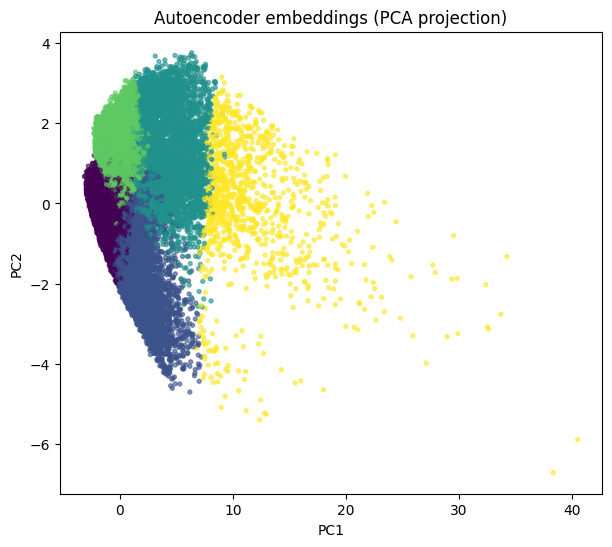

In [16]:
if HAS_MPL:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=42)
    Z_2d = pca.fit_transform(Z)

    plt.figure(figsize=(7, 6))
    plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=clusters, s=8, alpha=0.6)
    plt.title('Autoencoder embeddings (PCA projection)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()
else:
    print('Matplotlib not available; skipping PCA plot.')